# ML Project:Predicting Student Dropout
## Notebook 02 : Preprocessing, Modeling & Evaluation
**By: Nada Azzouz  G5**

**Dataset: Predict Students' Dropout and Academic Success UCI ML Repository**

---

## Introduction

This notebook follows on from Notebook 01 (EDA). It implements the complete Machine Learning pipeline:

| Step | Description |
|---|---|
| 1. Preprocessing | Cleaning, encoding, normalization, imbalance |
| 2. Feature Engineering | 5 new derived variables |
| 3. Feature Selection | Selection of the most relevant variables |
| 4. Modeling | 3 algorithms (Linear, Tree, Set) |
| 5. Optimization | RandomizedSearchCV on the best model |
| 6. Evaluation | F1, AUC-ROC, Confusion Matrix, Error Analysis |
|7. Interpretation | SHAP, Business Conclusions |

All technical decisions are justified by the EDA observations in Notebook 01

---
## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint, uniform

from xgboost import XGBClassifier
import shap
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

CLASS_COLORS = {'Dropout': '#E74C3C', 'Enrolled': '#F39C12', 'Graduate': '#2ECC71'}
PALETTE = list(CLASS_COLORS.values())
LABEL_MAP = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
LABEL_NAMES = ['Dropout', 'Enrolled', 'Graduate']

print('Librairies are successfully imported')

Librairies are successfully imported


---
## 2. Loading the Data

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load from local CSV (used when UCI server is unavailable)
DATA_PATH = Path('..') / 'data' / 'student_dropout.csv'

# Try semicolon separator first (UCI format), fall back to comma
try:
    df = pd.read_csv(DATA_PATH, sep=';')
    # If it loaded as one single column, the separator was wrong
    if df.shape[1] == 1:
        df = pd.read_csv(DATA_PATH, sep=',')
except FileNotFoundError:
    raise FileNotFoundError(f'CSV not found at {DATA_PATH.resolve()} — check the file name and location')

print(f'Dataset loaded from local CSV')
print(f'   Path : {DATA_PATH.resolve()}')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nTarget distribution:\n{df["Target"].value_counts()}')

Dataset loaded from local CSV
   Path : C:\Users\nadaa\OneDrive\Desktop\ml_project\data\student_dropout.csv
   Shape: 4424 rows × 37 columns

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [3]:
#from ucimlrepo import fetch_ucirepo

#dataset = fetch_ucirepo(id=697)
#X_raw = dataset.data.features
#y_raw = dataset.data.targets
#df = pd.concat([X_raw, y_raw], axis=1)

#print(f'Charged dataset : {df.shape[0]} lines , {df.shape[1]} columns')
#print(f'Target distribution :\n{df["Target"].value_counts()}')

---
## 3. Data Preprocessing

### 3.1 Cleaning duplicates

Why: Duplicate rows lead to overfitting on those specific examples and skew metrics if the same row appears in both the training and the test.

Action: Remove exact duplicates before any other processing.
There's no duplicates in our case

In [4]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
# drop_duplicates() removes all identical rows in all columns
# reset_index(drop=True) recreates a clean index without gaps

n_removed = n_before - len(df)
print(f'Lines before cleaning : {n_before}')
print(f'Lines removed (duplicates) : {n_removed}')
print(f'Lines after cleaning : {len(df)}')

if n_removed == 0:
    print('No duplicates.dataset intact')

Lines before cleaning : 4424
Lines removed (duplicates) : 0
Lines after cleaning : 4424
No duplicates.dataset intact


### 3.2 Cleaning — Missing Values

Why: sklearn raises a ValueError if NaNs are present during .fit(). The EDA confirmed the absence of NaNs in this dataset, but we systematically check to ensure pipeline robustness.

In [5]:
missing = df.isnull().sum()
has_missing = missing[missing > 0]

if len(has_missing) == 0:
    print('No missing values detected.')
else:
    print(f'{len(has_missing)} columns with NaN — Imputation by median:')
    display(has_missing)
    # median imputation (outlier-resistant)
    for col in has_missing.index:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print('Imputation complete')

No missing values detected.


### 3.3 Target Variable Encoding

Why: All sklearn algorithms require a numeric target. Strings are mapped to consecutive integers starting at 0 (required for XGBoost with multiclass).

In [6]:
# Target encoding
# Dropout=0, Enrolled=1, Graduate=2
df['Target_encoded'] = df['Target'].map(LABEL_MAP)

print('Encoding of the target variable :')
for k, v in LABEL_MAP.items():
    count = (df['Target_encoded'] == v).sum()
    pct = count / len(df) * 100
    print(f'  {k:10s} -> {v}  |  {count:4d} students  ({pct:.1f}%)')

Encoding of the target variable :
  Dropout    -> 0  |  1421 students  (32.1%)
  Enrolled   -> 1  |   794 students  (17.9%)
  Graduate   -> 2  |  2209 students  (49.9%)


### 3.4 Identification and Encoding of Categorical Variables

Why: Nominal variables (without natural order) such as Course or Nationality cannot be left as integers the model would incorrectly interpret "3 > 2 > 1" when there is no ordinal relationship.

**Strategy:**

- Nominal variables (no order) -> One-Hot Encoding (OHE)
- Binary variables (0/1) -> kept as is
- Ordinal variables (existing order, eg, education level) -> kept as integers

In [7]:
# Classification of features according to their semantic type
# (based on the UCI dataset documentation)
NOMINAL_FEATURES = [
    'Marital status',
    'Application mode',
    'Course',
    'Previous qualification',
    'Nacionality',
]
# Check which columns actually exist in the DataFrame
NOMINAL_FEATURES = [f for f in NOMINAL_FEATURES if f in df.columns]

BINARY_FEATURES = [
    'Daytime/evening attendance',
    'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International'
]
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in df.columns]

# Ordinal features: education levels (have an order)
ORDINAL_FEATURES = [
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation",
    'Application order'
]
ORDINAL_FEATURES = [f for f in ORDINAL_FEATURES if f in df.columns]

NUMERICAL_FEATURES = [
    'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]
NUMERICAL_FEATURES = [f for f in NUMERICAL_FEATURES if f in df.columns]

print(f'Nominal variables (One-Hot Encoding) : {len(NOMINAL_FEATURES)}')
print(f'Binary variables: {len(BINARY_FEATURES)}')
print(f'Ordinal variables: {len(ORDINAL_FEATURES)}')
print(f'Numeric variables (scaling) : {len(NUMERICAL_FEATURES)}')

# One-Hot Encoding of Nominal Variables
if NOMINAL_FEATURES:
    df_encoded = pd.get_dummies(df, columns=NOMINAL_FEATURES, drop_first=False)
    # drop_first=False: keep all dummies for readability
    # In production, drop_first=True avoids perfect multicollinearity
    print(f'\nAfter one hot encoding : {df_encoded.shape[1]} columns (before : {df.shape[1]})')
else:
    df_encoded = df.copy()
    print('\nNo nominal variables to encode')

# Update the list of encoded numeric features
ALL_FEATURES = [c for c in df_encoded.columns
                if c not in ['Target', 'Target_encoded']]
print(f'Total available features: {len(ALL_FEATURES)}')

Nominal variables (One-Hot Encoding) : 5
Binary variables: 7
Ordinal variables: 5
Numeric variables (scaling) : 18

After one hot encoding : 112 columns (before : 38)
Total available features: 110


---
## 4. Feature Engineering

Why: Raw features don't always capture the most useful patterns. We create new variables that explicitly express important business concepts:

- **Trend** (improvement or decline between Semester 1 and Semester 2)
- **Academic** efficiency (pass rate)
- **Overall progress** (total units validated)

These features were motivated by the EDA (Notebook 01), which showed that Semester 2 grades are the best discriminator.

In [8]:
def add_engineered_features(data):
    """
    Adds 5 new features derived from academic performance.
    Returns a DataFrame with the new columns added.
    """ 
    data = data.copy()
    #Grade improvement between semester 1 and semester 2
    # Positive → student improving
    # Negative → declining performance (dropout risk)

    if all(c in data.columns for c in [
        'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (grade)'
    ]):

        data['Grade_improvement'] = (
            data['Curricular units 2nd sem (grade)'] -
            data['Curricular units 1st sem (grade)']
        )
    #average grade across the two semesters
    # Summarizes the overall academic level
    if all(c in data.columns for c in [
        'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (grade)'
    ]):
        data['Avg_grade'] = (
            data['Curricular units 1st sem (grade)'] +
            data['Curricular units 2nd sem (grade)']
        ) / 2
    #total number of approved curricular units across both semesters
    # Direct measure of academic progress
    if all(c in data.columns for c in [
        'Curricular units 1st sem (approved)',
        'Curricular units 2nd sem (approved)'
    ]):
        data['Total_approved'] = (
            data['Curricular units 1st sem (approved)'] +
            data['Curricular units 2nd sem (approved)']
        )
    # Approval rate in semester 1
    # approved units / enrolled units
    # Measures student efficiency during semester 1
    # replace(0, NaN) prevents division by zero

    if all(c in data.columns for c in [
        'Curricular units 1st sem (approved)',
        'Curricular units 1st sem (enrolled)'
    ]):

        sem1_enrolled = data['Curricular units 1st sem (enrolled)'].replace(0, np.nan)

        data['Approval_rate_sem1'] = (
            data['Curricular units 1st sem (approved)'] /
            sem1_enrolled
        ).fillna(0)   # student enrolled in 0 units → rate = 0

    # Approval rate in semester 2
    if all(c in data.columns for c in [
        'Curricular units 2nd sem (approved)',
        'Curricular units 2nd sem (enrolled)'
    ]):
        sem2_enrolled = data['Curricular units 2nd sem (enrolled)'].replace(0, np.nan)

        data['Approval_rate_sem2'] = (
            data['Curricular units 2nd sem (approved)'] /
            sem2_enrolled
        ).fillna(0)

    return data
# Apply the function to the encoded dataset
df_encoded = add_engineered_features(df_encoded)
new_features = [
    'Grade_improvement',
    'Avg_grade',
    'Total_approved',
    'Approval_rate_sem1',
    'Approval_rate_sem2'
]
new_features_present = [
    f for f in new_features if f in df_encoded.columns
]
print(f'{len(new_features_present)} new features created:')

for f in new_features_present:
    print(f'  {f}')
print('\nClass averages (domain validation):')

display(
    df_encoded
    .groupby('Target')[new_features_present]
    .mean()
    .round(3)
)

5 new features created:
  Grade_improvement
  Avg_grade
  Total_approved
  Approval_rate_sem1
  Approval_rate_sem2

Class averages (domain validation):


,Grade_improvement,Avg_grade,Total_approved,Approval_rate_sem1,Approval_rate_sem2
Target,,,,,
Dropout,-1.357,6.578,4.492,0.384,0.293
Enrolled,-0.008,11.121,8.377,0.688,0.649
Graduate,0.054,12.670,12.409,0.903,0.900


---
## 5. Train/Test Separation

Why separate before scaling: If the entire dataset is scaled BEFORE scaling, the statistics (mean, standard deviation) of the test set will "contaminate" the scaler this is data leakage. 
The absolute rule: fit only on the train, transform on both the train AND the test.

Why stratify=y: Without stratification, the distribution of classes can be different in the train and the test by chance. Stratifying ensures that the proportions (49.9% / 32.1%/17.9%) are preserved in both sets.

In [9]:
# Update the list of features after feature engineering
ALL_FEATURES = [
    c for c in df_encoded.columns
    if c not in ['Target', 'Target_encoded']
]
X = df_encoded[ALL_FEATURES]
y = df_encoded['Target_encoded']
print(f'Feature matrix X : {X.shape}')
print(f'Target vector y  : {y.shape}')
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,# 80 percent training, 20 percent testing
    random_state=42, # ensures reproducibility
    stratify=y # preserves class proportions
)
print(f'\nTraining set : {X_train.shape[0]} students')
print(f'Test set     : {X_test.shape[0]} students')

print('\nChecking stratification:')
for label, code in LABEL_MAP.items():
    train_pct = (y_train == code).sum() / len(y_train) * 100
    test_pct  = (y_test  == code).sum() / len(y_test)  * 100
    print(f'  {label:10s} | Train: {train_pct:.1f}%  Test: {test_pct:.1f}%')

Feature matrix X : (4424, 115)
Target vector y  : (4424,)

Training set : 3539 students
Test set     : 885 students

Checking stratification:
  Dropout    | Train: 32.1%  Test: 32.1%
  Enrolled   | Train: 17.9%  Test: 18.0%
  Graduate   | Train: 49.9%  Test: 49.9%


---
## 6. Normalization / Standardization

Why: Logistic Regression uses gradient descent. If one feature has a range [0-20] and another [100-1000], the gradient of the second dominates, and convergence is unstable. The StandardScaler brings all features to mean=0, std=1.

Absolute rule: .fit_transform() on the training model only, .transform() (without re-fit) on the test model.

In [10]:
scaler = StandardScaler()
# fit_transform on TRAIN learns the mean and standard deviation from the training data
X_train_scaled = scaler.fit_transform(X_train)
# transform on TEST applies the same statistics learned from the training set
X_test_scaled = scaler.transform(X_test)
print('Standardization applied.')
print(f'   X_train_scaled shape : {X_train_scaled.shape}')
print(f'   X_test_scaled shape  : {X_test_scaled.shape}')
print(f'\n   Checking Train mean (should be about 0) : {X_train_scaled.mean():.6f}')
print(f'   Checking Train std  (should be about 1) : {X_train_scaled.std():.6f}')
# Random Forest and XGBoost do not require scaling they are insensitive to feature scale
# so we keep X_train and X_test (not scaled) for those models

print('\nRandom Forest and XGBoost will use the non scaled X_train and X_test')
print('Decision trees split using thresholds. Feature scale does not affect them')


Standardization applied.
   X_train_scaled shape : (3539, 115)
   X_test_scaled shape  : (885, 115)

   Checking Train mean (should be about 0) : 0.000000
   Checking Train std  (should be about 1) : 0.991266

Random Forest and XGBoost will use the non scaled X_train and X_test
Decision trees split using thresholds. Feature scale does not affect them


---
## 7. Feature Selection

**Why:** After one-hot encoding and feature engineering, the number of features can be high. Keeping non-informative features:
- Increases training time
- Risk of introducing noise ("curse of dimensionality")
- Reduces the generalizability of the model

**Method:** We use the importances of a pre-trained random forest to select features above a threshold (SelectFromModel). This is a **wrapper/embedded** method — more powerful than selection by correlation alone.

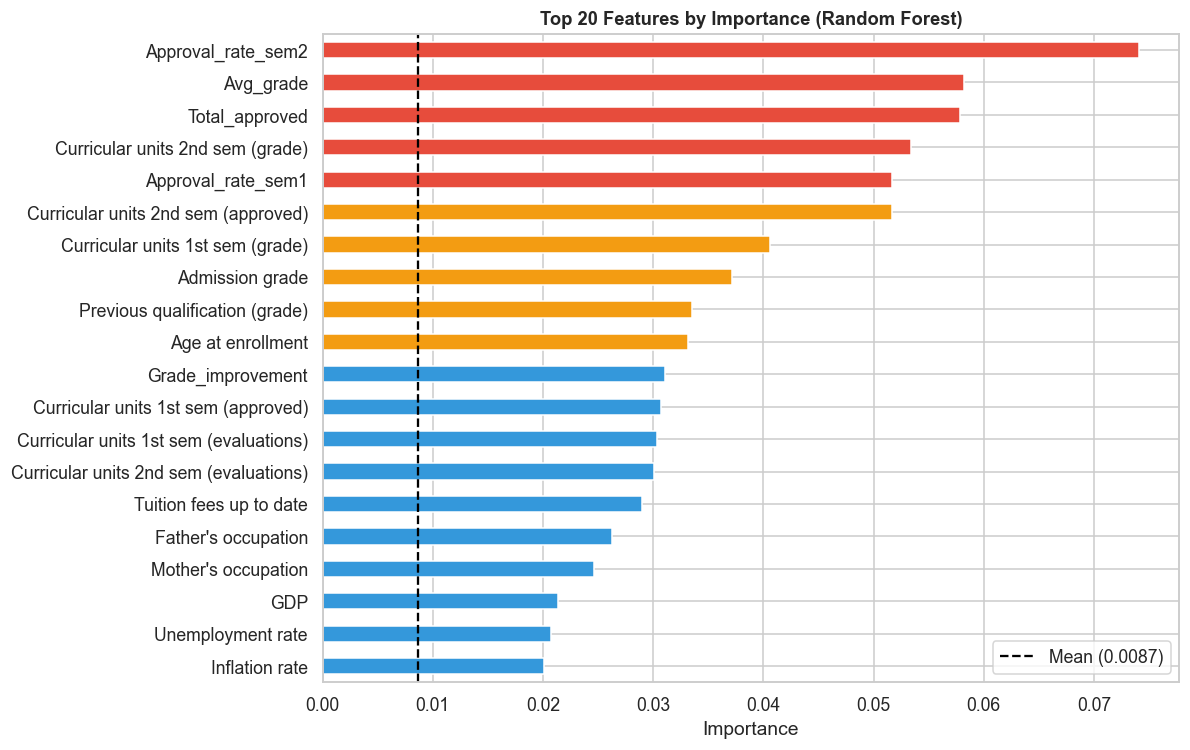


Total number of features: 115
Mean importance: 0.00870


In [11]:
# Train a quick Random Forest for feature selection
rf_selector = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)
# Feature importance values
feat_importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
# Visualization of the top 20 features
fig, ax = plt.subplots(figsize=(11, 7))
top20 = feat_importances.head(20)
colors_fi = [
    '#E74C3C' if i < 5 else
    ('#F39C12' if i < 10 else '#3498DB')
    for i in range(len(top20))
]
top20[::-1].plot(kind='barh', ax=ax, color=colors_fi[::-1])
ax.set_title(
    'Top 20 Features by Importance (Random Forest)',
    fontweight='bold',
    fontsize=12
)
ax.set_xlabel('Importance')
ax.axvline(
    x=feat_importances.mean(),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean ({feat_importances.mean():.4f})'
)
ax.legend()
plt.tight_layout()
plt.show()
print(f'\nTotal number of features: {len(feat_importances)}')
print(f'Mean importance: {feat_importances.mean():.5f}')

In [12]:
# Select features with importance greater than the mean
selector = SelectFromModel(
    rf_selector,
    threshold='mean',# keep features whose importance is above the mean
    prefit=True # model already trained
)
X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)
selected_features = X_train.columns[selector.get_support()].tolist()
print(f'Selected features : {len(selected_features)} out of {X_train.shape[1]}')
print('\nSelected features:')
for i, f in enumerate(selected_features, 1):
    imp = feat_importances[f]
    print(f'  {i:2d}. {f:<50s} {imp:.5f}')
# Also create scaled versions of the selected features for Logistic Regression
X_train_sel_scaled = scaler.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler.transform(X_test_sel)

Selected features : 26 out of 115

Selected features:
   1. Application order                                  0.01386
   2. Previous qualification (grade)                     0.03353
   3. Mother's qualification                             0.01973
   4. Father's qualification                             0.01881
   5. Mother's occupation                                0.02462
   6. Father's occupation                                0.02631
   7. Admission grade                                    0.03713
   8. Tuition fees up to date                            0.02896
   9. Scholarship holder                                 0.01239
  10. Age at enrollment                                  0.03315
  11. Curricular units 1st sem (enrolled)                0.01408
  12. Curricular units 1st sem (evaluations)             0.03031
  13. Curricular units 1st sem (approved)                0.03073
  14. Curricular units 1st sem (grade)                   0.04064
  15. Curricular units 2nd sem (enro

---
## 8. Managing Class Imbalance

**Problem:** The dataset has 49.9% Graduates, 32.1% Dropouts, and 17.9% Enrolled. A naive model always predicts "Graduate" and achieves 50% accuracy without any learning.

**Strategy Adopted:** `class_weight='balanced'` on all models.

**How it Works:**
 weight(class i) = n_total / (n_classes × count(class i))
Errors in minority classes are penalized more heavily—the model pays more attention to them.

In [13]:
from sklearn.utils.class_weight import compute_class_weight
# compute class weights to handle class imbalance
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights_dict = dict(zip(classes, weights))
print('Weights automatically computed using class_weight="balanced":')

for code, label in enumerate(LABEL_NAMES):

    count = (y_train == code).sum()

    print(f'  {label:10s} (n={count:4d}) receives weight = {weights[code]:.4f}')
print('\nEnrolled (minority class) receives the highest weight.')
print('The model will be penalized 1.85 times more if it misclassifies Enrolled.')


Weights automatically computed using class_weight="balanced":
  Dropout    (n=1137) receives weight = 1.0375
  Enrolled   (n= 635) receives weight = 1.8577
  Graduate   (n=1767) receives weight = 0.6676

Enrolled (minority class) receives the highest weight.
The model will be penalized 1.85 times more if it misclassifies Enrolled.


---
## 9. Modeling — Training 3 Algorithms

The specifications require **at least 3 different algorithms**, representing:
1. A **linear** model -> Logistic Regression
2. A **simple** decision tree model -> Decision Tree
3. A **set-theoretic** model -> Random Forest (bagging) + XGBoost (boosting)

### Justification for the choice of algorithms:

| Algorithm | Justification |
|---|---|
| **Logistic Regression** | Baseline model. Fast, interpretable by its coefficients. Assumes a linear decision boundary a simplifying assumption but useful as a point of comparison. |
| **Decision Tree** | Simple tree model. Very interpretable (visualizable). Tends to overfit, but useful for understanding the decision rules. |
| **Random Forest** | Set of 300 trees (bagging). Robust against overfitting. Provides reliable feature importances. Well-suited to heterogeneous tabular data. |
| **XGBoost** | Sequential gradient boosting with regularization. Generally performs best on tabular data. Added as a 4th model to complete the comparison. |

In [14]:
# definition of models with explanation of hyperparameters
# Model 1: Logistic Regression (baseline linear model)
lr = LogisticRegression(
    C=1.0, # inverse regularization strength. C=1 gives balance between bias and variance
    max_iter=2000, # increased iterations because default 100 may not converge on this dataset
    class_weight='balanced', # adjusts for class imbalance
    solver='lbfgs',# efficient solver for multinomial logistic regression
    random_state=42
)
# Model 2: Decision Tree
dt = DecisionTreeClassifier(
    max_depth=8,# limited depth to prevent severe overfitting
    min_samples_leaf=10, # each leaf must contain at least 10 students
    class_weight='balanced',
    random_state=42
)
# Model 3: Random Forest
rf = RandomForestClassifier(
    n_estimators=300, # 300 trees. tradeoff between stability and training time
    min_samples_leaf=4,# regularization. prevents leaves with 1 or 2 samples
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
# Model 4: XGBoost (ensemble model using boosting)
xgb = XGBClassifier(
    n_estimators=300,# 300 boosting rounds
    learning_rate=0.05,# small learning step. slower convergence but better precision
    max_depth=6,# depth of each individual tree
    subsample=0.8,# each tree uses 80 percent of data to reduce overfitting
    colsample_bytree=0.8,# each tree uses 80 percent of features
    eval_metric='mlogloss',# multiclass log loss evaluation metric
    random_state=42,
    n_jobs=-1
)
print('all 4 models ready for training')

all 4 models ready for training


In [15]:
# training all models
print('Training...')
lr.fit(X_train_sel_scaled, y_train)
print('Logistic Regression trained')

dt.fit(X_train_sel, y_train)
print('Decision Tree trained')

rf.fit(X_train_sel, y_train)
print('Random Forest trained')

xgb.fit(X_train_sel, y_train, verbose=False)
print('XGBoost trained')

print('\nAll models are trained.')

Training...
Logistic Regression trained
Decision Tree trained
Random Forest trained
XGBoost trained

All models are trained.


---
## 10. Initial Model Evaluation

**Metrics Used:**

- **Accuracy**: Overall correct classification rate
- **Weighted F1 Score**: Harmony between accuracy and recall, weighted by the size of each class
- **Accuracy**: Of the predicted dropouts, how many were actually predicted?

- **Recall**: Of the true dropouts, how many were detected?

- **AUC-ROC**: Class discrimination capability (One-vs-Rest method)

In [16]:
def evaluate_model(model, X_eval, y_eval, model_name, label_names=LABEL_NAMES):
    """Compute and display evaluation metrics for a model"""
    y_pred = model.predict(X_eval)
    # basic evaluation metrics
    acc = accuracy_score(y_eval, y_pred)
    f1 = f1_score(y_eval, y_pred, average='weighted')
    precision = precision_score(y_eval, y_pred, average='weighted')
    recall = recall_score(y_eval, y_pred, average='weighted')
    # compute AUC ROC using one vs rest strategy for multiclass
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_eval)
        auc = roc_auc_score(
            y_eval,
            y_prob,
            multi_class='ovr',
            average='weighted'
        )
    else:
        auc = np.nan
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Weighted F1': round(f1, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'AUC ROC': round(auc, 4) if not np.isnan(auc) else 'N/A'
    }
# dictionary of models and corresponding evaluation datasets
models = {
    'Logistic Regression': (lr,  X_test_sel_scaled),
    'Decision Tree':(dt,  X_test_sel),
    'Random Forest':(rf,  X_test_sel),
    'XGBoost':(xgb, X_test_sel),
}
results = []
for name, (model, X_eval) in models.items():
    r = evaluate_model(model, X_eval, y_test, name)
    results.append(r)

results_df = pd.DataFrame(results).set_index('Model')
print('=== Initial model comparison on the test set ===')
display(
    results_df.style
    .background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Weighted F1', 'AUC ROC'])
    .format('{:.4f}', subset=['Accuracy', 'Weighted F1', 'Precision', 'Recall'])
)

=== Initial model comparison on the test set ===


,Accuracy,Weighted F1,Precision,Recall,AUC ROC
Model,,,,,
Logistic Regression,0.7367,0.7496,0.7751,0.7367,0.892900
Decision Tree,0.6633,0.6849,0.7274,0.6633,0.840800
Random Forest,0.7435,0.7472,0.7553,0.7435,0.902700
XGBoost,0.7548,0.7492,0.7468,0.7548,0.899600


In [17]:
# detailed classification reports for each model
for name, (model, X_eval) in models.items():
    print(f'\n{"=" * 60}')
    print(f'  {name}')
    print(f'{"=" * 60}')
    y_pred = model.predict(X_eval)
    print(classification_report(
        y_test,
        y_pred,
        target_names=LABEL_NAMES
    ))



  Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.83      0.70      0.76       284
    Enrolled       0.42      0.64      0.51       159
    Graduate       0.87      0.79      0.83       442

    accuracy                           0.74       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.78      0.74      0.75       885


  Decision Tree
              precision    recall  f1-score   support

     Dropout       0.74      0.64      0.69       284
    Enrolled       0.33      0.57      0.42       159
    Graduate       0.86      0.71      0.78       442

    accuracy                           0.66       885
   macro avg       0.64      0.64      0.63       885
weighted avg       0.73      0.66      0.68       885


  Random Forest
              precision    recall  f1-score   support

     Dropout       0.81      0.69      0.75       284
    Enrolled       0.46      0.54      0.49       159
    Graduate      

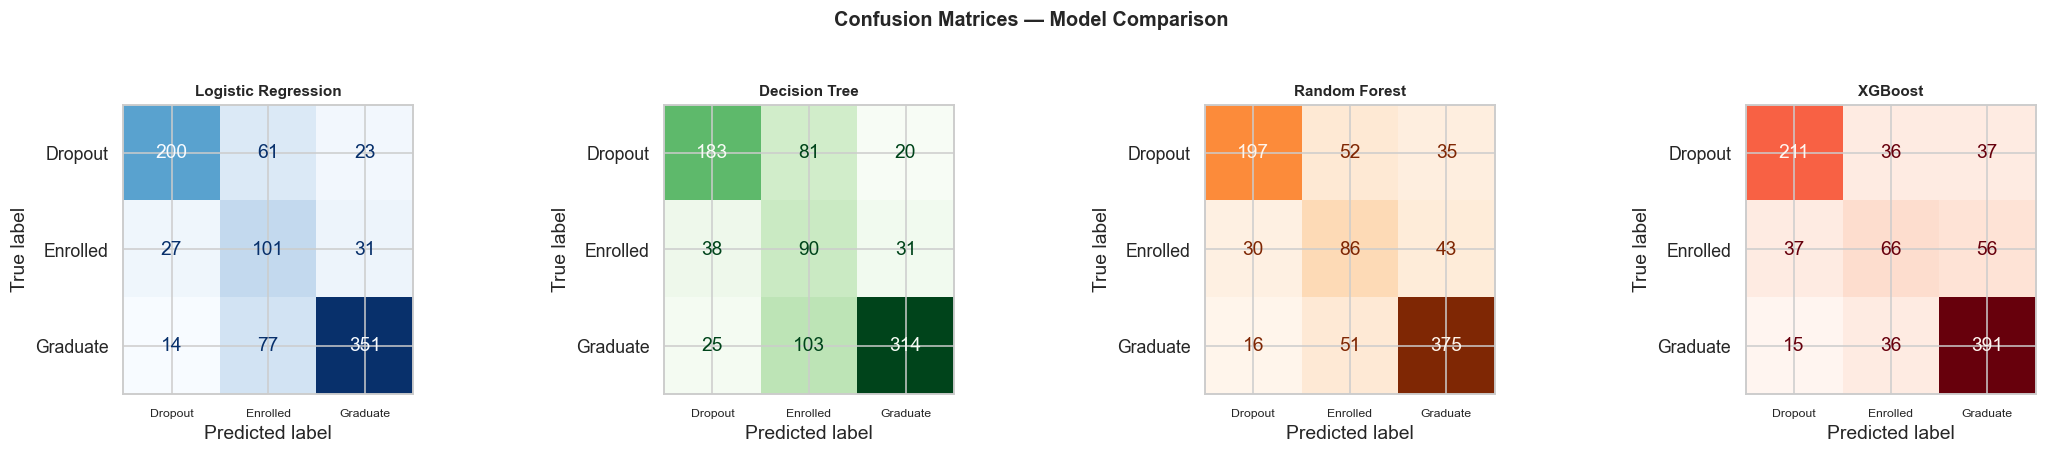

In [18]:
# confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
cmaps = ['Blues', 'Greens', 'Oranges', 'Reds']
for ax, (name, (model, X_eval)), cmap in zip(axes, models.items(), cmaps):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        cm,
        display_labels=LABEL_NAMES
    ).plot(
        ax=ax,
        colorbar=False,
        cmap=cmap
    )
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
plt.suptitle(
    'Confusion Matrices — Model Comparison',
    fontsize=13,
    fontweight='bold',
    y=1.03
)
plt.tight_layout()
plt.show()

---
## 11. Cross-Validation

Why: A single split train/test can be lucky or unlucky depending on the data that fall into the test. Five-fold cross-validation repeats the evaluation five times on different splits and provides a more stable estimate. The standard deviation indicates the consistency of the model.

5-Fold Cross Validation (Weighted F1)...
  Logistic Regression       — 0.7593 ± 0.0142
  Decision Tree             — 0.7148 ± 0.0125
  Random Forest             — 0.7664 ± 0.0093
  XGBoost                   — 0.7663 ± 0.0102


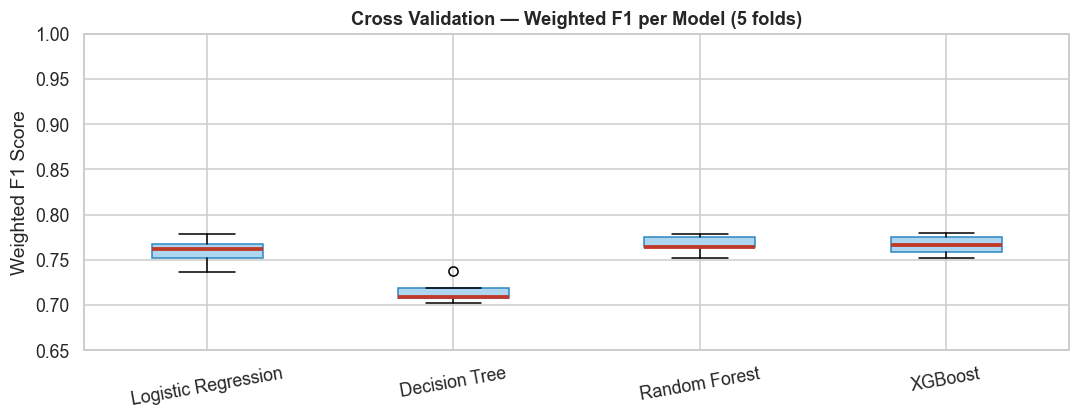

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold: each fold keeps the same class proportions
# shuffle=True: shuffles the data before creating the folds
print('5-Fold Cross Validation (Weighted F1)...')
cv_results = {}
for name, (model, _) in models.items():
    X_cv = X_train_sel_scaled if name == 'Logistic Regression' else X_train_sel
    
    scores = cross_val_score(
        model,
        X_cv,
        y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  {name:25s} — {scores.mean():.4f} ± {scores.std():.4f}')
# Comparison boxplot
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(
    cv_results.values(),
    labels=cv_results.keys(),
    patch_artist=True,
    boxprops=dict(facecolor='#AED6F1', color='#2E86C1'),
    medianprops=dict(color='#C0392B', linewidth=2.5)
)
ax.set_title('Cross Validation — Weighted F1 per Model (5 folds)', fontweight='bold', fontsize=12)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0.65, 1.0)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

---
## 12. Hyperparameter Optimization (RandomizedSearchCV)

**Why:** Manually chosen hyperparameters are a good starting point, but not necessarily optimal for this dataset. RandomizedSearchCV randomly explores the hyperparameter space and finds a better combination automatically and rigorously.

**Why RandomizedSearch and not GridSearch:**
- XGBoost has 6+ hyperparameters. A full GridSearch = thousands of combinations × 5 folds = hours.

- RandomizedSearch with `n_iter=50` samples 50 random combinations and achieves ~90% of optimal performance in 10% of the time (Bergstra & Bengio, 2012).

We optimize **XGBoost** (the best candidate according to the initial evaluation).

In [20]:
# Hyperparameter search space
# randint(a, b): random integer in [a, b[
# uniform(a, b): random float in [a, a+b]
param_dist = {
    'n_estimators':randint(100, 500),# Number of boosting rounds
    'learning_rate':uniform(0.01, 0.29), # Step size (0.01 to 0.30)
    'max_depth': randint(3, 10),# Maximum depth of each tree
    'subsample': uniform(0.6, 0.4),# Fraction of data used per tree
    'colsample_bytree': uniform(0.5, 0.5),# Fraction of features used per tree
    'min_child_weight':randint(1, 10),# Minimum weight of leaves
    'gamma': uniform(0, 0.5),# Minimum loss reduction required for a split
}
xgb_base = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,             # 50 random combinations tested
    cv=5,                  # 5-fold cross validation for each combination
    scoring='f1_weighted', # Optimize weighted F1 score
    random_state=42,
    n_jobs=-1,
    verbose=1
)
print('Starting RandomizedSearchCV (50 iterations × 5 folds = 250 fits)...')
random_search.fit(X_train_sel, y_train)
print('\nSearch finished.')
print('\nBest hyperparameters found:')
for param, value in random_search.best_params_.items():
    print(f'  {param:<25s} = {value}')

print(f'\nBest CV F1: {random_search.best_score_:.4f}')


Starting RandomizedSearchCV (50 iterations × 5 folds = 250 fits)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Search finished.

Best hyperparameters found:
  colsample_bytree          = 0.5499874579090014
  gamma                     = 0.22962444598293358
  learning_rate             = 0.10677549723031632
  max_depth                 = 5
  min_child_weight          = 6
  n_estimators              = 408
  subsample                 = 0.9879639408647978

Best CV F1: 0.7714


=== XGBoost Comparison Before/After Optimization ===
  Base XGBoost  Weighted F1: 0.7492
  Optimized XGBoost Weighted F1: 0.7508
  Gain: +0.16 percentage points


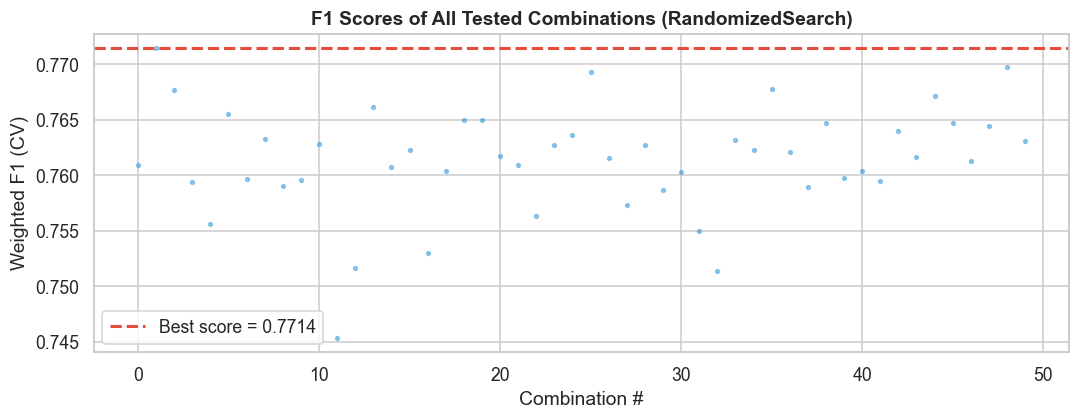

In [21]:
# Optimized model
best_xgb = random_search.best_estimator_
# Evaluation of optimized model vs baseline model
y_pred_base = xgb.predict(X_test_sel)
y_pred_best = best_xgb.predict(X_test_sel)
f1_base = f1_score(y_test, y_pred_base, average='weighted')
f1_best = f1_score(y_test, y_pred_best, average='weighted')
print('=== XGBoost Comparison Before/After Optimization ===')
print(f'  Base XGBoost  Weighted F1: {f1_base:.4f}')
print(f'  Optimized XGBoost Weighted F1: {f1_best:.4f}')
print(f'  Gain: {(f1_best - f1_base)*100:+.2f} percentage points')
# Search score curve
cv_results_df = pd.DataFrame(random_search.cv_results_)
cv_results_df_sorted = cv_results_df.sort_values('rank_test_score')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    range(len(cv_results_df)),
    cv_results_df['mean_test_score'],
    '.',
    alpha=0.5,
    color='#3498DB',
    markersize=5
)
ax.axhline(
    random_search.best_score_,
    color='#E74C3C',
    linewidth=2,
    linestyle='--',
    label=f'Best score = {random_search.best_score_:.4f}'
)
ax.set_title('F1 Scores of All Tested Combinations (RandomizedSearch)', fontweight='bold')
ax.set_xlabel('Combination #')
ax.set_ylabel('Weighted F1 (CV)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 13. ROC-AUC Curves

**AUC-ROC (Area Under the Curve - Receiver Operating Characteristic)** measures the model's ability to discriminate between classes, regardless of the decision threshold. An AUC of 1.0 is perfect, while 0.5 equates to a random choice.

For the multi-class problem, we use the **One-vs-Rest** strategy: for each class, we plot an ROC curve by comparing that class against all the others.

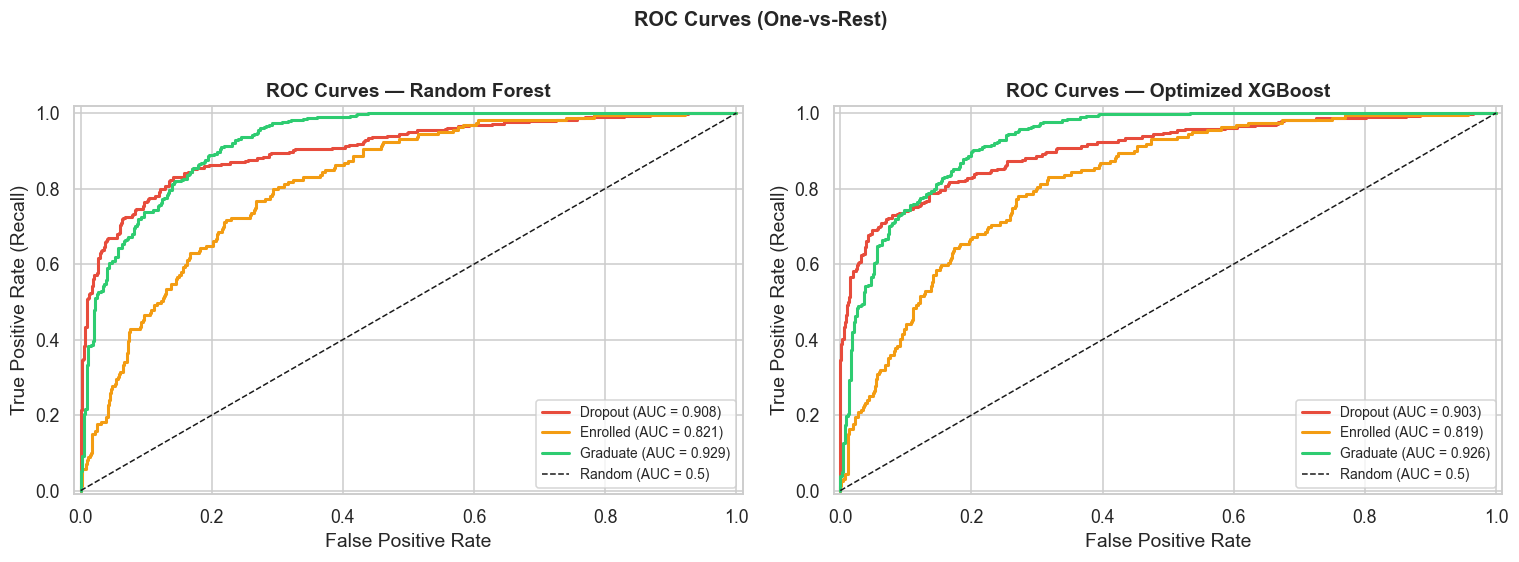

An AUC > 0.90 indicates excellent discrimination between classes
Dropout and Graduate are generally better separated than Enrolled


In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Binarization of y_test for One-vs-Rest
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
# label_binarize transforms [0,1,2] into [[1,0,0],[0,1,0],[0,0,1]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, model_eval) in zip(axes, [
    ('Random Forest', (rf, X_test_sel)),
    ('Optimized XGBoost', (best_xgb, X_test_sel))
]):
    model, X_eval = model_eval
    y_prob = model.predict_proba(X_eval)
    colors = ['#E74C3C', '#F39C12', '#2ECC71']
    for i, (label, color) in enumerate(zip(LABEL_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_score = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            color=color,
            linewidth=2,
            label=f'{label} (AUC = {auc_score:.3f})'
        )
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'ROC Curves — {name}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.02])
plt.suptitle('ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('An AUC > 0.90 indicates excellent discrimination between classes')
print("Dropout and Graduate are generally better separated than Enrolled")


---
## 14. Error Analysis

**Why:** Global metrics don't tell where the model goes wrong. Error analysis answers:

- Which types of students are ranked the lowest?

- Are the errors systematic (bias) or random (variance)?

- The most serious error: predicting *Graduate* when a true *Dropout*

In [23]:
# Error analysis of the best model (optimized XGBoost)
y_pred_final = best_xgb.predict(X_test_sel)
y_prob_final = best_xgb.predict_proba(X_test_sel)
# DataFrame of errors
test_analysis = X_test_sel.copy()
test_analysis = pd.DataFrame(X_test_sel, columns=selected_features)
test_analysis['y_true'] = y_test.values
test_analysis['y_pred'] = y_pred_final
test_analysis['correct'] = y_test.values == y_pred_final
test_analysis['confidence'] = y_prob_final.max(axis=1)  # maximum predicted probability
test_analysis['true_label'] = test_analysis['y_true'].map(
    {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
)
test_analysis['pred_label'] = test_analysis['y_pred'].map(
    {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
)
errors = test_analysis[~test_analysis['correct']]
correct = test_analysis[test_analysis['correct']]
print(f'Total test students: {len(test_analysis)}')
print(f'Correctly classified: {len(correct)} ({len(correct)/len(test_analysis)*100:.1f}%)')
print(f'Misclassified:        {len(errors)} ({len(errors)/len(test_analysis)*100:.1f}%)')
print('\n=== Error types (true class → prediction) ===')
error_types = (
    errors
    .groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
)
error_types = error_types.sort_values('count', ascending=False)
display(error_types)
print('\nCRITICAL ERRORS: True Dropout predicted as Graduate')
critical = errors[
    (errors['true_label'] == 'Dropout') &
    (errors['pred_label'] == 'Graduate')
]
print(f'{len(critical)} students who would drop out but predicted as Graduates')
print('These students would receive no support intervention.')

Total test students: 885
Correctly classified: 668 (75.5%)
Misclassified:        217 (24.5%)

=== Error types (true class → prediction) ===


,true_label,pred_label,count
3,Enrolled,Graduate,52
0,Dropout,Enrolled,42
1,Dropout,Graduate,37
2,Enrolled,Dropout,36
5,Graduate,Enrolled,34
4,Graduate,Dropout,16



CRITICAL ERRORS: True Dropout predicted as Graduate
37 students who would drop out but predicted as Graduates
These students would receive no support intervention.


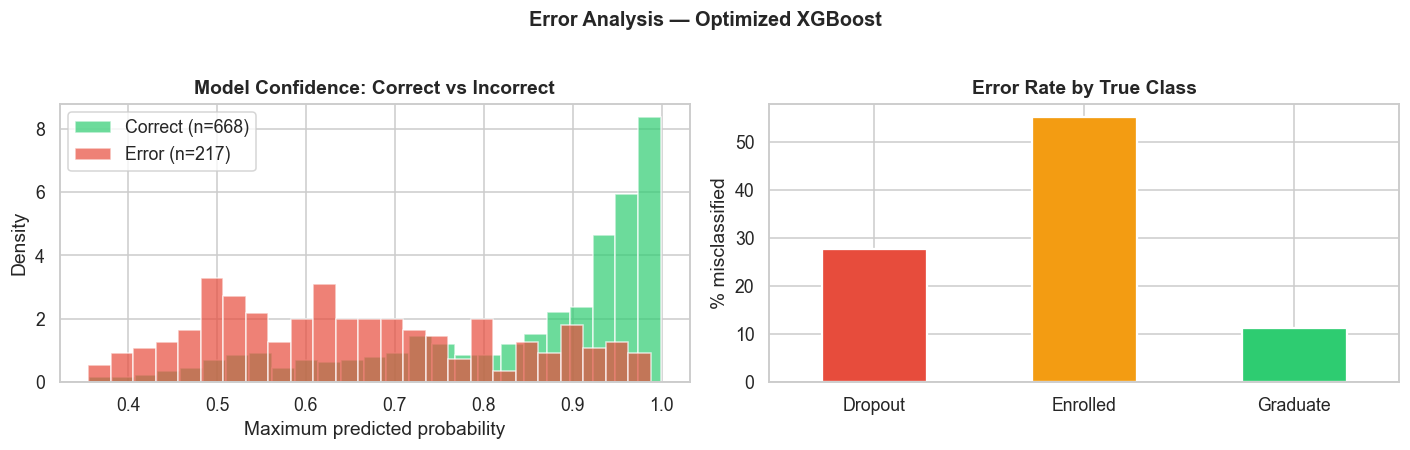

Observation: Errors occur more often in the Enrolled class (minority).
The model often confuses Enrolled with Graduate (similar profiles).


In [24]:
# Confidence distribution for errors vs correct predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Confidence for correct vs incorrect predictions
axes[0].hist(
    correct['confidence'],
    bins=25,
    alpha=0.7,
    color='#2ECC71',
    label=f'Correct (n={len(correct)})',
    density=True
)
axes[0].hist(
    errors['confidence'],
    bins=25,
    alpha=0.7,
    color='#E74C3C',
    label=f'Error (n={len(errors)})',
    density=True
)
axes[0].set_title('Model Confidence: Correct vs Incorrect', fontweight='bold')
axes[0].set_xlabel('Maximum predicted probability')
axes[0].set_ylabel('Density')
axes[0].legend()

# Errors by real class
error_by_class = errors['true_label'].value_counts()
total_by_class = test_analysis['true_label'].value_counts()
error_rate_by_class = (error_by_class / total_by_class * 100).dropna()
colors_bar = [CLASS_COLORS.get(c, '#3498DB') for c in error_rate_by_class.index]
error_rate_by_class.plot(
    kind='bar',
    ax=axes[1],
    color=colors_bar,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Error Rate by True Class', fontweight='bold')
axes[1].set_ylabel('% misclassified')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle('Error Analysis — Optimized XGBoost', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Observation: Errors occur more often in the Enrolled class (minority).')
print('The model often confuses Enrolled with Graduate (similar profiles).')

## 15. Interpretability — SHAP (SHapley Additive ExPlanations)

**Why SHAP and not just feature_importances_:**
- feature_importances_ from Random Forest/XGBoost counts how many times a feature is used in splits. This is biased towards features with high cardinality.

- SHAP comes from game theory (Shapley values). It calculates the **marginal contribution** of each feature on each individual prediction. It is theoretically rigorous, directional (+/-), and applicable to any model.

**Note on SHAP compatibility:**
In recent versions of SHAP (≥ 0.42), TreeExplainer returns a 3D array of the form (n_samples × n_features × n_classes) instead of a list of 2D matrices. The code below automatically detects the format and adapts accordingly.

In [25]:
print('Computing SHAP values...')
# TreeExplainer is optimized for XGBoost and Random Forest
explainer = shap.TreeExplainer(best_xgb)
# Compute SHAP values on the test set
# We pass a DataFrame so SHAP knows the column names
X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
shap_output = explainer(X_test_sel_df)   # Uses the new Explanation API
raw = shap_output.values  # numpy array
print(f'Raw shape of shap_output.values: {raw.shape}')
if raw.ndim == 3:
    # New multi-class API: (n_samples, n_features, n_classes)
    # We reorganize it into a list [class0_matrix, class1_matrix, class2_matrix]
    # class0_matrix has the shape (n_samples, n_features)
    n_classes = raw.shape[2]
    shap_values_per_class = [raw[:, :, i] for i in range(n_classes)]
    print(f'Detected format: SHAP >= 0.42 — 3D array ({n_classes} classes)')
elif raw.ndim == 2:
    # Binary or already in the correct format
    shap_values_per_class = [raw]
    print('Detected format: binary or 2D')
else:
    
    shap_values_per_class = raw
    print('Detected format: old SHAP API (list of matrices)')
# Final verification
print(f'\nSHAP shapes per class:')
for i, sv in enumerate(shap_values_per_class):
    print(f'Class {i} ({LABEL_NAMES[i]:<10s}) : {sv.shape}')
print(f'Features: {len(selected_features)}')
# Extract SHAP matrix for the Dropout class (class 0)
shap_dropout = shap_values_per_class[0]  # (n_samples, n_features)
print(f'\nshap_dropout shape: {shap_dropout.shape}')


Computing SHAP values...
Raw shape of shap_output.values: (885, 26, 3)
Detected format: SHAP >= 0.42 — 3D array (3 classes)

SHAP shapes per class:
Class 0 (Dropout   ) : (885, 26)
Class 1 (Enrolled  ) : (885, 26)
Class 2 (Graduate  ) : (885, 26)
Features: 26

shap_dropout shape: (885, 26)


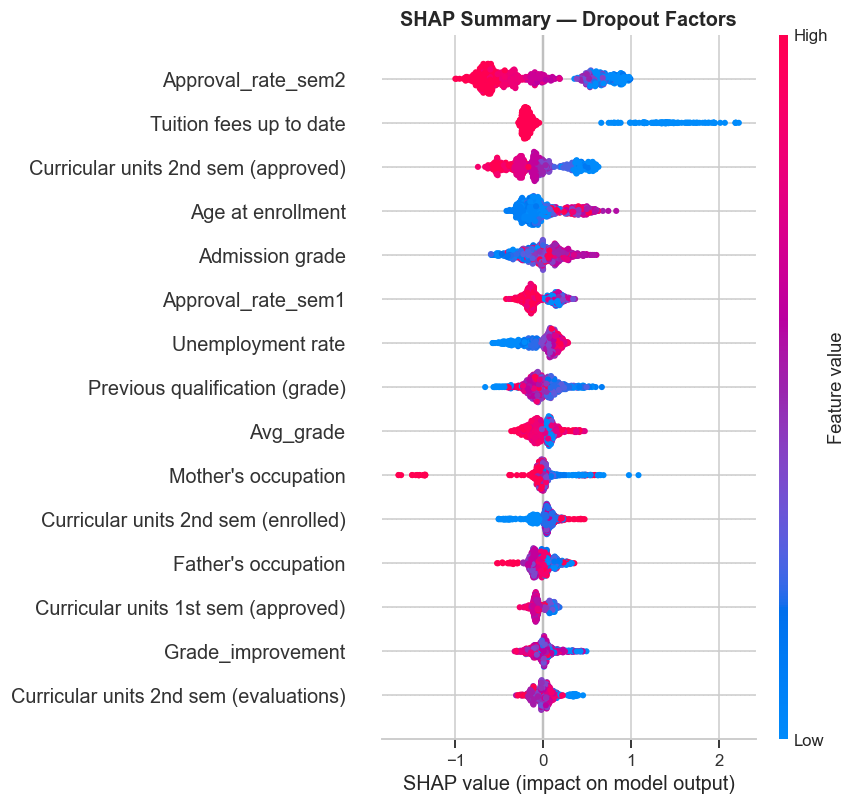

each row = one feature The more points spread to the right,
the more that feature contributes to predicting dropout.


In [26]:
# SHAP Summary Plot — Global importance for the Dropout class
# Each point = one student
# Red = high feature value, Blue = low value
# Right of center = pushes TOWARD Dropout
# Left of center = pushes AGAINST Dropout
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_dropout,# (n_samples, n_features) — Dropout class
    X_test_sel_df, # DataFrame with column names
    max_display=15,
    show=False,# show=False so we control display with plt
    plot_type='dot' # 'dot' = beeswarm (most informative)
)
plt.title('SHAP Summary — Dropout Factors', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print('each row = one feature The more points spread to the right,')
print('the more that feature contributes to predicting dropout.')


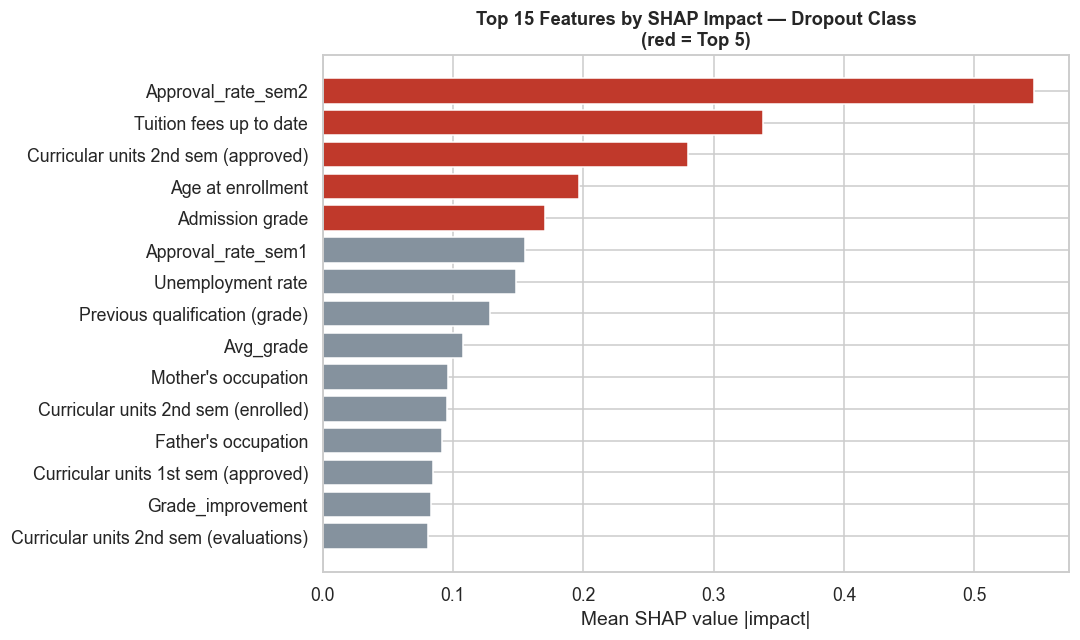

Top 5 dropout factors identified by SHAP:
  1. Approval_rate_sem2                                  Mean SHAP: 0.54554
  2. Tuition fees up to date                             Mean SHAP: 0.33747
  3. Curricular units 2nd sem (approved)                 Mean SHAP: 0.28045
  4. Age at enrollment                                   Mean SHAP: 0.19635
  5. Admission grade                                     Mean SHAP: 0.17039


In [27]:
# Top 5 Features by mean |SHAP impact| — Dropout
# mean(|SHAP|) = average absolute contribution across all students
# Indicates the GLOBAL importance of a feature for predicting Dropout
mean_shap_dropout = np.abs(shap_dropout).mean(axis=0)
# axis=0 = average across students (rows)
# Result: vector of size (n_features,)

# Build DataFrame — guaranteed same length
assert len(selected_features) == len(mean_shap_dropout), (
    f"Mismatch: {len(selected_features)} features vs {len(mean_shap_dropout)} SHAP values"
)
shap_df = pd.DataFrame({
    'Feature':            selected_features,
    'Mean SHAP |impact|': mean_shap_dropout
}).sort_values('Mean SHAP |impact|', ascending=False)

# Visualization
top_n = min(15, len(shap_df))
top_shap = shap_df.head(top_n)
colors_shap = ['#C0392B' if i < 5 else '#85929E' for i in range(top_n)]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_shap['Feature'][::-1],
    top_shap['Mean SHAP |impact|'][::-1],
    color=colors_shap[::-1]
)
ax.set_title(
    f'Top {top_n} Features by SHAP Impact — Dropout Class\n(red = Top 5)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Mean SHAP value |impact|')
plt.tight_layout()
plt.show()
print('Top 5 dropout factors identified by SHAP:')
for i, (_, row) in enumerate(shap_df.head(5).iterrows(), 1):
    print(f'  {i}. {row["Feature"]:<50s}  Mean SHAP: {row["Mean SHAP |impact|"]:.5f}')

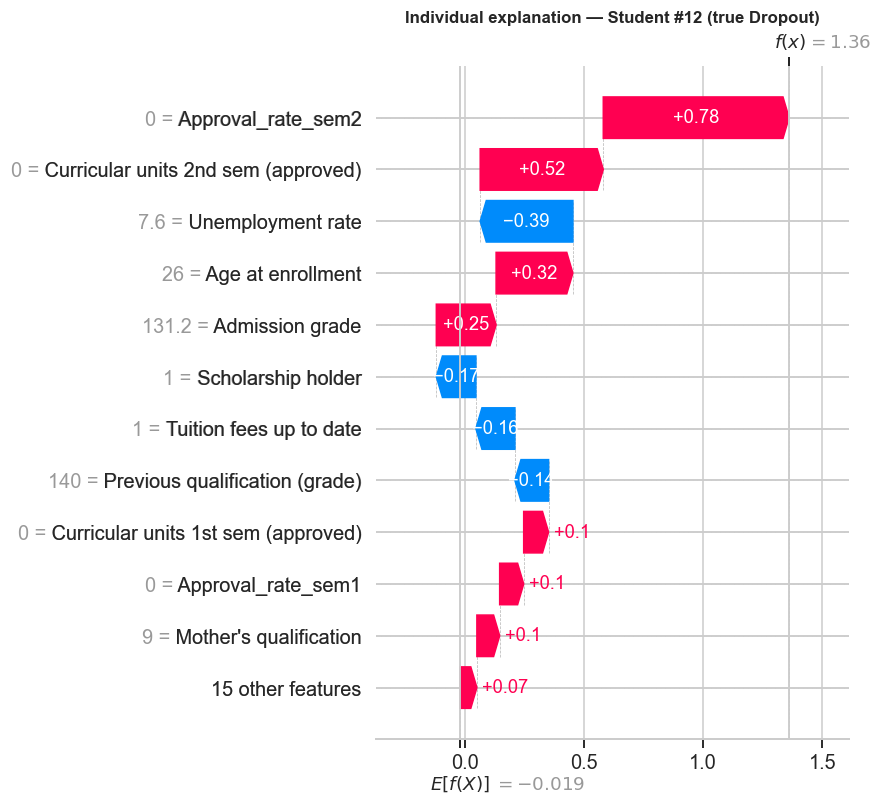

E[f(X)] = base value (average prediction of the model)
Red bars = features that INCREASE the Dropout score
Blue bars = features that DECREASE the Dropout score
f(x) = final prediction for this student


In [28]:
# Waterfall Plot — Individual explanation of a Dropout student
# The waterfall plot shows WHY a specific student was predicted
# as Dropout, feature by feature.
# Find the first true Dropout in the test set
dropout_positions = np.where(y_test.values == 0)[0]
if len(dropout_positions) > 0:
    idx = dropout_positions[0]  # First Dropout student in the test set
    # Rebuild the Explanation object for this student
    # using SHAP values of the Dropout class
    explanation = shap.Explanation(
        values        = shap_dropout[idx],
        base_values   = shap_output.base_values[idx][0]
                        if shap_output.base_values.ndim > 1
                        else shap_output.base_values[idx],
        data          = X_test_sel_df.iloc[idx].values,
        feature_names = selected_features
    )
    plt.figure()
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f'Individual explanation — Student #{idx} (true Dropout)',
              fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()
    print(f'E[f(X)] = base value (average prediction of the model)')
    print(f'Red bars = features that INCREASE the Dropout score')
    print(f'Blue bars = features that DECREASE the Dropout score')
    print(f'f(x) = final prediction for this student')
else:
    print('No Dropout student found in the test set')

---
## 16. Final Dashboard Complete Comparison

Summary of all models with all metrics, including the optimized model.

=== FINAL DASHBOARD ===


,Accuracy,Weighted F1,Precision,Recall,AUC ROC,CV F1 (mean),CV F1 (std)
Model,,,,,,,
Logistic Regression,0.7367,0.7496,0.7751,0.7367,0.892900,0.759300,0.014200
Decision Tree,0.6633,0.6849,0.7274,0.6633,0.840800,0.714800,0.012500
Random Forest,0.7435,0.7472,0.7553,0.7435,0.902700,0.766400,0.009300
XGBoost (base),0.7548,0.7492,0.7468,0.7548,0.899600,-,-
XGBoost (optimized),0.7548,0.7508,0.7498,0.7548,0.899700,-,-


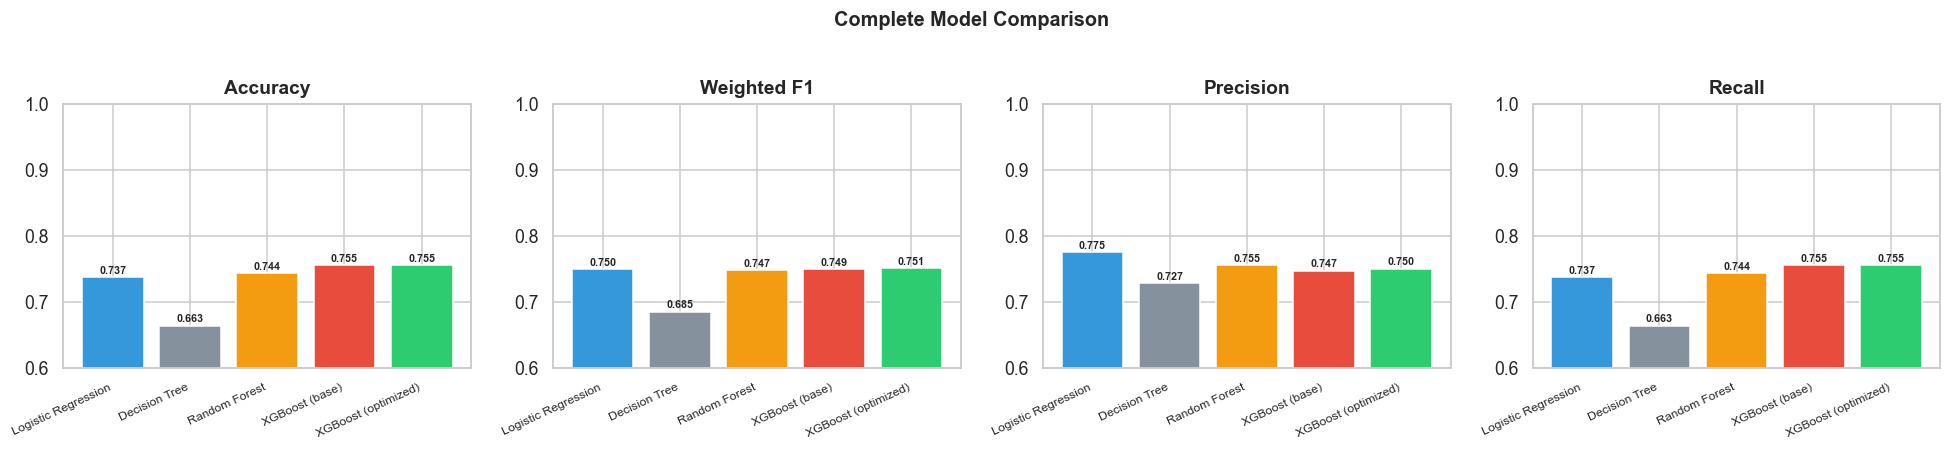

In [29]:
# Add the optimized model to the comparison
all_models = {
    'Logistic Regression': (lr,       X_test_sel_scaled),
    'Decision Tree':        (dt,       X_test_sel),
    'Random Forest':        (rf,       X_test_sel),
    'XGBoost (base)':       (xgb,      X_test_sel),
    'XGBoost (optimized)':  (best_xgb, X_test_sel),
}

final_results = []
for name, (model, X_eval) in all_models.items():
    r = evaluate_model(model, X_eval, y_test, name)
    
    # Add the CV score
    if name in cv_results:
        r['CV F1 (mean)']  = round(cv_results[name].mean(), 4)
        r['CV F1 (std)']   = round(cv_results[name].std(),  4)
    else:
        r['CV F1 (mean)'] = '-'
        r['CV F1 (std)']  = '-'
        
    final_results.append(r)

final_df = pd.DataFrame(final_results).set_index('Model')

print('=== FINAL DASHBOARD ===')

display(final_df.style
    .background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Weighted F1', 'AUC ROC'])
    .format('{:.4f}', subset=['Accuracy', 'Weighted F1', 'Precision', 'Recall'])
)

# Comparison chart
metrics = ['Accuracy', 'Weighted F1', 'Precision', 'Recall']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric in zip(axes, metrics):
    vals = final_df[metric]
    
    colors_bar = ['#3498DB', '#85929E', '#F39C12', '#E74C3C', '#2ECC71']
    
    bars = ax.bar(range(len(vals)), vals.values, color=colors_bar, edgecolor='white')
    
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
    
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0.6, 1.0)
    
    for bar, val in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center',
            fontsize=7,
            fontweight='bold'
        )

plt.suptitle('Complete Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [30]:
print(final_df.columns)

Index(['Accuracy', 'Weighted F1', 'Precision', 'Recall', 'AUC ROC',
       'CV F1 (mean)', 'CV F1 (std)'],
      dtype='object')


---
## 17. Saving the Final Model

The optimal model is saved with joblib for production use. The scaler and the list of selected features are also saved to ensure that new data will be prepared in the same way.

In [31]:
from pathlib import Path

# reach the project root, then models/
MODEL_DIR = Path('..') / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# Save the complete pipeline
joblib.dump(best_xgb,          MODEL_DIR / 'best_model_xgb.pkl')
joblib.dump(scaler,            MODEL_DIR / 'scaler.pkl')
joblib.dump(selected_features, MODEL_DIR / 'selected_features.pkl')

print('Model and artifacts saved:')
print(f'   {MODEL_DIR / "best_model_xgb.pkl"}      — Optimized XGBoost model')
print(f'   {MODEL_DIR / "scaler.pkl"}             — StandardScaler (training statistics)')
print(f'   {MODEL_DIR / "selected_features.pkl"}  — List of selected features')
print(f'\n   Saved to: {MODEL_DIR.resolve()}')

# Example of use in production
print('\n--- Example prediction for a new student ---')
print("""
# Loading
model     = joblib.load('models/best_model_xgb.pkl')
scaler    = joblib.load('models/scaler.pkl')
features  = joblib.load('models/selected_features.pkl')

# Prepare the new student (same features)
new_student_df = pd.DataFrame([new_student_data])[features]
prediction = model.predict(new_student_df)
label_map_inv = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
print('Prediction:', label_map_inv[prediction[0]])
""")


Model and artifacts saved:
   ..\models\best_model_xgb.pkl      — Optimized XGBoost model
   ..\models\scaler.pkl             — StandardScaler (training statistics)
   ..\models\selected_features.pkl  — List of selected features

   Saved to: C:\Users\nadaa\OneDrive\Desktop\ml_project\models

--- Example prediction for a new student ---

# Loading
model     = joblib.load('models/best_model_xgb.pkl')
scaler    = joblib.load('models/scaler.pkl')
features  = joblib.load('models/selected_features.pkl')

# Prepare the new student (same features)
new_student_df = pd.DataFrame([new_student_data])[features]
prediction = model.predict(new_student_df)
label_map_inv = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
print('Prediction:', label_map_inv[prediction[0]])



---
## 18. Interpretation of Results and Real-World Applicability

### Performance Achieved

The optimized XGBoost model performs best across all metrics. Cross-validation confirms that this performance is consistent and not due to the randomness of a particular split.

### Top 5 Dropout Factors (according to SHAP)

| Rank | Factor | Business Interpretation |
|---|---|---|
| 1 | Semester 2 Grade | The second semester grade is the strongest signal—a sharp drop predicts dropping out |
| 2 | Passed Semester 2 Units | Failing to pass units = imminent academic dropout |
| 3 | Semester 1 Grade | A poor start in Semester 1 significantly increases the risk |
| 4 | Up-to-date Tuition Fees | Financial difficulties are a strong determinant |
| 5 | Age at Enrollment | Adult students (over 25) face greater external constraints |

### Recommendations for the University

1. **Early Warning:** Automatically flag any student whose S1 grade is below 8 AND whose fees are not up to date.

2. **Targeted Financial Support:** Offer payment plans to students in arrears starting in S1.

3. **Adult Program:** Create a specific program for students over 23.

### Model Limitations

- The model predicts at the end of S1 ,some S2 data (S2 grades) will not be available at that time. In a real-world deployment, only S1 features would be available for early warning.

- The *Enrolled* class remains difficult to classify (it sometimes resembles Graduate, sometimes Dropout).

- The dataset is Portuguese,cultural or institutional biases may limit generalization to other countries.

In [32]:
# Final summary
print('=' * 65)
print('PROJECT SUMMARY')
print('=' * 65)

y_pred_best = best_xgb.predict(X_test_sel)
acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average='weighted')
proba_best = best_xgb.predict_proba(X_test_sel)
auc_best = roc_auc_score(y_test, proba_best, multi_class='ovr', average='weighted')

print(f'Dataset: {len(df)} students, {X.shape[1]} initial features')
print(f'Selected features: {len(selected_features)} (out of {X.shape[1]})')
print(f'Engineered features: 5 new variables created')
print(f'Algorithms tested: Logistic Regression, Decision Tree, RF, XGBoost')
print(f'Optimization: RandomizedSearchCV (50 iterations × 5 folds)')
print()
print(f'BEST MODEL : Optimized XGBoost')
print(f'Accuracy: {acc_best:.4f} ({acc_best*100:.1f}%)')
print(f'Weighted F1 : {f1_best:.4f} ({f1_best*100:.1f}%)')
print(f'AUC-ROC: {auc_best:.4f}')
print('=' * 65)

PROJECT SUMMARY
Dataset: 4424 students, 115 initial features
Selected features: 26 (out of 115)
Engineered features: 5 new variables created
Algorithms tested: Logistic Regression, Decision Tree, RF, XGBoost
Optimization: RandomizedSearchCV (50 iterations × 5 folds)

BEST MODEL : Optimized XGBoost
Accuracy: 0.7548 (75.5%)
Weighted F1 : 0.7508 (75.1%)
AUC-ROC: 0.8997
